# Exercise - VaR

------------------------------------

In [1]:
%pip install openpyxl
%pip install --upgrade openpyxl
!mamba install statsmodels
%pip install statsmodels jinja2

import pandas as pd
import numpy as np
import openpyxl
import statsmodels.api as sm
import matplotlib.pyplot as plt

mambajs 0.19.13

Process pip requirements ...

mambajs 0.19.13

Process pip requirements ...

Requirement openpyxl already satisfied.
mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, statsmodels
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.2805 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ pandas                        3.0.0                         np22py313h9d9dc1e_0           emscripten-forge              
+ patsy                         1.0.2                         py313h1804a44_0               emscripten-forge              
+ python-tzdata                 2025.3                        pyhd8ed1ab_0                  conda-forge                   
+ statsmodels                   0.14.6         

In [2]:
excel_path = "/drive/notebooks/FINM37600/Data/spx_returns_weekly.xlsx"
sheet_name = "spx returns"

------------------------------------

# 1. Diversification

In [12]:
# --- Load weekly returns ---
rets = pd.read_excel(excel_path, sheet_name)

tickers = ["AAPL", "META", "NVDA", "TSLA"]
R = rets[tickers].apply(pd.to_numeric, errors="coerce").dropna()

alpha = 0.05
ANN_FACTOR = 252  

def empirical_var(x):
    return x.quantile(alpha)

def empirical_cvar(x):
    v = x.quantile(alpha)
    return x[x <= v].mean()

def risk_stats(df_or_series, label=None):
    """
    Returns a 3-row DataFrame: Vol (annualized), VaR 0.05 (weekly), CVaR 0.05 (weekly).
    Accepts a DataFrame (multiple series) or a Series (single series).
    """
    if isinstance(df_or_series, pd.Series):
        df = df_or_series.to_frame(name=label or df_or_series.name or "series")
    else:
        df = df_or_series.copy()

    out = pd.DataFrame(index=["Vol", "VaR 0.05", "CVaR 0.05"], columns=df.columns, dtype=float)

    for c in df.columns:
        x = df[c].dropna()
        out.loc["Vol", c] = x.std(ddof=1) * np.sqrt(ANN_FACTOR)   # annualized
        out.loc["VaR 0.05", c] = empirical_var(x)                # empirical weekly
        out.loc["CVaR 0.05", c] = empirical_cvar(x)              # empirical weekly

    return out

def fmt_pct(df, decimals=2):
    return df.apply(lambda col: col.map(lambda v: f"{v*100:.{decimals}f}%"))

### Calculating volatility, empirical VaR (.05), empirical CVaR (.05).


In [4]:
stats_1 = risk_stats(R)
stats_1_fmt = fmt_pct(stats_1, decimals=1)
stats_1_fmt

,AAPL,META,NVDA,TSLA
Vol,61.4%,78.5%,102.7%,131.1%
VaR 0.05,-5.7%,-7.2%,-8.7%,-12.1%
CVaR 0.05,-8.4%,-10.4%,-11.7%,-15.0%


### Forming an equally-weighted portfolio of the investments.

In [5]:
R_2 = R.copy()
R_2["Portfolio"] = R_2.mean(axis=1)

stats_2 = risk_stats(R_2)
stats_2_fmt = fmt_pct(stats_2, decimals=1)
stats_2_fmt

,AAPL,META,NVDA,TSLA,Portfolio
Vol,61.4%,78.5%,102.7%,131.1%,70.3%
VaR 0.05,-5.7%,-7.2%,-8.7%,-12.1%,-6.2%
CVaR 0.05,-8.4%,-10.4%,-11.7%,-15.0%,-8.6%


### Recalculating EW portfolio, but dropping most volatile asset, and replace the portion it was getting with 0. 

In [13]:
R["Portfolio"] = R[tickers].mean(axis=1) 

w = 1 / len(tickers)  # 0.25

# 1) "stand-alone TSLA" = TSLA's contribution inside the Portfolio (0.25 * TSLA)
R["Stand-Alone TSLA"] = w * R["TSLA"]

# 2) "portfolio-ex TSLA" = renormalize remaining weights to sum to 1 (mean of the other 3)
R["Portfolio-ex TSLA"] = R[["AAPL", "META", "NVDA"]].mean(axis=1)

# Build stats table
cols = ["AAPL", "META", "NVDA", "TSLA", "Portfolio", "Portfolio-ex TSLA", "Stand-Alone TSLA"]
out = pd.DataFrame(index=["vol", "VaR 0.05", "CVaR 0.05"], columns=cols, dtype=float)

for c in cols:
    x = R[c].dropna()
    out.loc["vol", c] = x.std(ddof=1) * np.sqrt(ANN_FACTOR)     # annualized vol 
    out.loc["VaR 0.05", c] = x.quantile(alpha)                  # empirical weekly VaR
    out.loc["CVaR 0.05", c] = x[x <= x.quantile(alpha)].mean()  # empirical weekly CVaR

out_fmt = out.apply(lambda col: col.map(lambda v: f"{v*100:.1f}%"))
out_fmt

,AAPL,META,NVDA,TSLA,Portfolio,Portfolio-ex TSLA,Stand-Alone TSLA
vol,61.4%,78.5%,102.7%,131.1%,70.3%,64.9%,32.8%
VaR 0.05,-5.7%,-7.2%,-8.7%,-12.1%,-6.2%,-5.7%,-3.0%
CVaR 0.05,-8.4%,-10.4%,-11.7%,-15.0%,-8.6%,-8.2%,-3.8%


------------------

# 2. Dynamic Measures of EW Portfolio using window of 26.

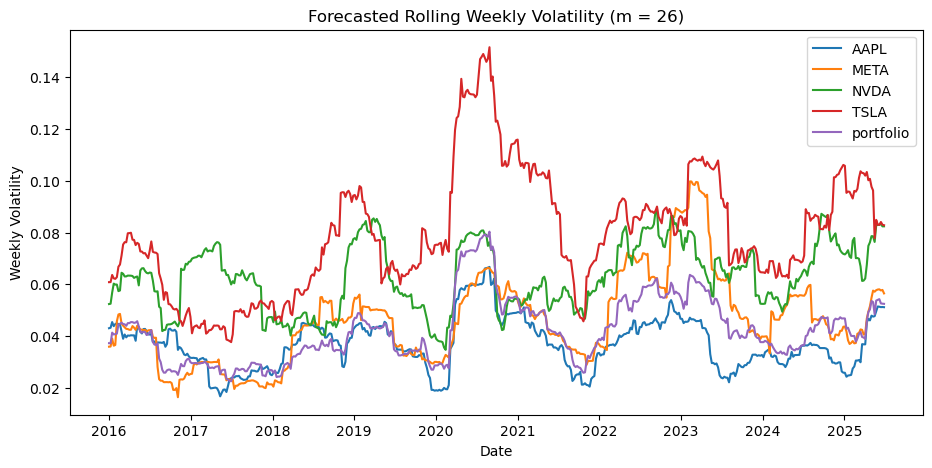

In [7]:
# Load + date index
rets = pd.read_excel(excel_path, sheet_name=sheet_name)
date_col = rets.columns[0]
rets[date_col] = pd.to_datetime(rets[date_col])
rets = rets.set_index(date_col).sort_index()

tickers = ["AAPL", "META", "NVDA", "TSLA"]
R = rets[tickers].apply(pd.to_numeric, errors="coerce").dropna(how="any")

# 1.2 portfolio
R["portfolio"] = R.mean(axis=1)

m = 26

# forecasted rolling vol: σ_t uses data through t-1
sigma = R.rolling(window=m).std(ddof=1).shift(1)

# Plot rolling vol for all series
plt.figure(figsize=(11, 5))
for col in sigma.columns:
    plt.plot(sigma.index, sigma[col], label=col)
plt.title("Forecasted Rolling Weekly Volatility (m = 26)")
plt.xlabel("Date")
plt.ylabel("Weekly Volatility")
plt.legend()
plt.show()

In [14]:
from scipy.stats import norm

alpha = 0.05
z_05 = -1.65
mu = 0.0
ANN_FACTOR = 252

# end-of-sample forecasted vols
sigma_T = sigma.dropna().iloc[-1]  # one value per column at end of sample

# conditional (normal) VaR/CVaR at end of sample
VaR_cond = mu + z_05 * sigma_T
CVaR_cond = mu - sigma_T * (norm.pdf(z_05) / alpha)

# annualized vol at end of sample
vol_ann = sigma_T * np.sqrt(ANN_FACTOR)

results_21 = pd.DataFrame(
    {"Vol (ann)": vol_ann, "Normal VaR(0.05)": VaR_cond, "Normal CVaR(0.05)": CVaR_cond}
)

(results_21 * 100).round(2)

# Unconditional (empirical) VaR/CVaR from full sample
uncond_VaR = R.quantile(alpha)
uncond_CVaR = R.apply(lambda x: x[x <= x.quantile(alpha)].mean())

compare = pd.DataFrame(
    {
        ("VaR", "Unconditional"): uncond_VaR,
        ("VaR", "Conditional)"): VaR_cond,
        ("CVaR", "Unconditional"): uncond_CVaR,
        ("CVaR", "Conditional"): CVaR_cond,
    }
)

(compare * 100).round(1).astype(str) + "%"


VaR                       CVaR            
                  Unconditional Conditional) Unconditional Conditional
AAPL                      -5.7%        -8.4%         -8.4%      -10.5%
META                      -7.2%        -9.3%        -10.4%      -11.6%
NVDA                      -8.7%       -13.6%        -11.7%      -16.9%
Portfolio                 -6.2%          NaN         -8.6%         NaN
Portfolio-ex TSLA         -5.7%          NaN         -8.2%         NaN
Stand-Alone TSLA          -3.0%          NaN         -3.8%         NaN
TSLA                     -12.1%       -13.7%        -15.0%      -16.9%
portfolio                   NaN        -8.7%           NaN      -10.7%

### Comparing volatility (annualized), normal VaR (.05), normal CVaR (.05).

In [9]:
vol_annualized = sigma_T * np.sqrt(ANN_FACTOR)
normal_VaR = mu + z_05 * sigma_T
normal_CVaR = mu - sigma_T * (norm.pdf(z_05) / alpha)

# Report table
report_stats = pd.DataFrame(
    {
        "Volatility (annualized)": vol_annualized,
        "Normal VaR (0.05)": normal_VaR,
        "Normal CVaR (0.05)": normal_CVaR,
    }
)

(report_stats * 100).round(1).astype(str) + "%"

,Volatility (annualized),Normal VaR (0.05),Normal CVaR (0.05)
AAPL,81.3%,-8.4%,-10.5%
META,89.7%,-9.3%,-11.6%
NVDA,130.8%,-13.6%,-16.9%
TSLA,131.5%,-13.7%,-16.9%
portfolio,83.3%,-8.7%,-10.7%


--------------------------

### Backtesting the VaR using the hit test. The percentage of “hits” is reported using both the expanding volatility and rolling volatility.


In [15]:
import numpy as np
import pandas as pd

alpha = 0.05
z_05 = -1.65
mu = 0.0
m = 26

tickers = ["AAPL", "META", "NVDA", "TSLA"]

if "Portfolio" not in R.columns:
    R["Portfolio"] = R[tickers].mean(axis=1)

series_list = tickers + ["Portfolio"]

hit_rates = {}

for s in series_list:
    r = R[s]

    # forecasted expanding vol: uses data through t-1
    sigma_exp = r.expanding(min_periods=2).std(ddof=1).shift(1)
    VaR_exp = mu + z_05 * sigma_exp

    # forecasted rolling vol: uses last m obs through t-1
    sigma_roll = r.rolling(window=m, min_periods=m).std(ddof=1).shift(1)
    VaR_roll = mu + z_05 * sigma_roll

    df = pd.DataFrame({"r": r, "VaR_exp": VaR_exp, "VaR_roll": VaR_roll}).dropna()

    hit_exp = (df["r"] < df["VaR_exp"]).mean()
    hit_roll = (df["r"] < df["VaR_roll"]).mean()

    hit_rates[s] = {"Expanding Hit Ratio": hit_exp, "Rolling Hit Ratio": hit_roll}

hit_table = pd.DataFrame(hit_rates).T

# format %
(hit_table * 100).round(1).astype(str) + "%"


,Expanding Hit Ratio,Rolling Hit Ratio
AAPL,4.0%,4.8%
META,4.6%,4.4%
NVDA,3.0%,4.4%
TSLA,5.8%,5.0%
Portfolio,4.8%,4.0%
